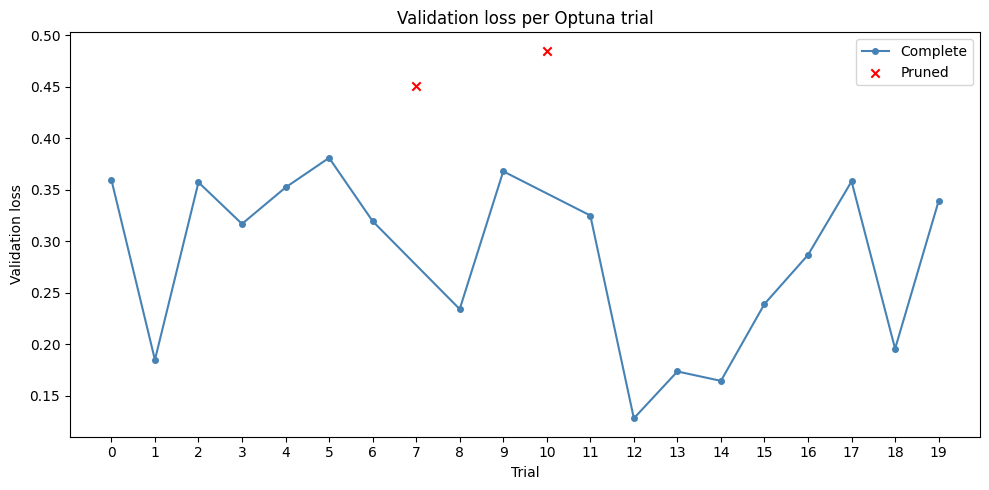

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('all_trials.csv').sort_values('number')

complete = df[df['state'] == 'COMPLETE']
pruned = df[df['state'] == 'PRUNED']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(complete['number'], complete['value'], marker='o', markersize=4, color='steelblue', label='Complete')
ax.scatter(pruned['number'], pruned['value'], marker='x', color='red', zorder=5, label='Pruned')

ax.set_xticks(df['number'])
ax.set_xlabel('Trial')
ax.set_ylabel('Validation loss')
ax.set_title('Validation loss per Optuna trial')
ax.legend()
plt.tight_layout()
plt.show()


/projects/e32998/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


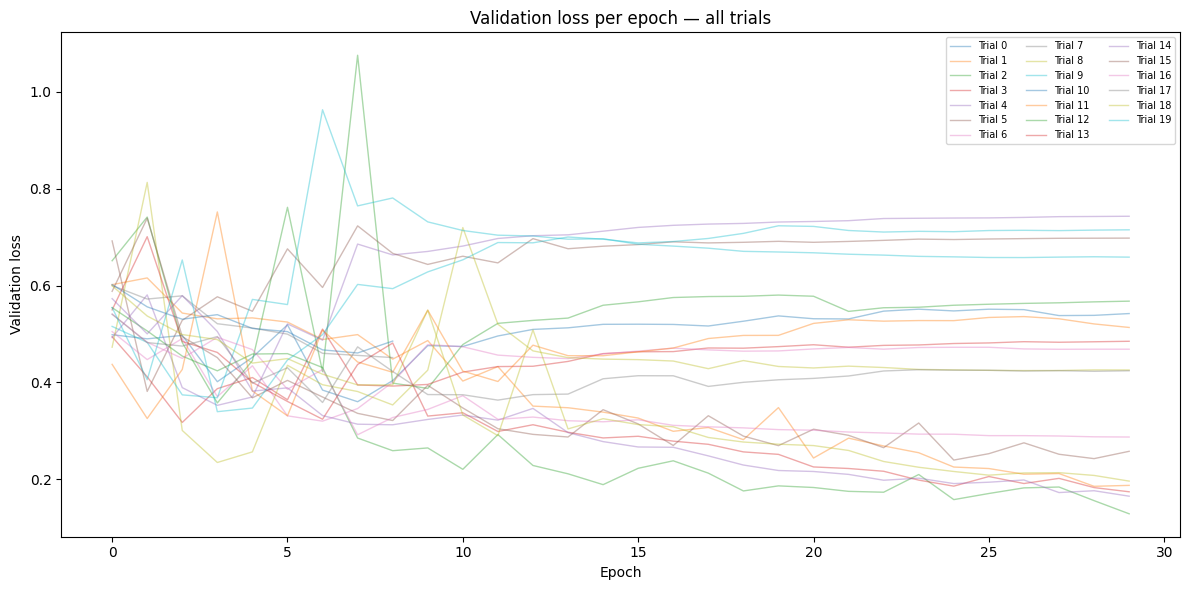

In [6]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt

study = optuna.load_study(
    study_name='mil_study',
    storage='sqlite:///optuna.db'
)

fig, ax = plt.subplots(figsize=(12, 6))

for trial in study.trials:
    if not trial.intermediate_values:
        continue
    epochs = sorted(trial.intermediate_values.keys())
    losses = [trial.intermediate_values[e] for e in epochs]
    ax.plot(epochs, losses, alpha=0.4, linewidth=1, label=f'Trial {trial.number}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation loss')
ax.set_title('Validation loss per epoch — all trials')
ax.legend(fontsize=7, ncol=3, loc='upper right')
plt.tight_layout()
plt.show()
